In [1]:
# =====================================
# 1. Install Required Libraries
# =====================================
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.7/887.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [2]:
# =====================================
# 2. Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import joblib
import os


In [3]:
# Set MLflow tracking URI (local for Colab)
mlflow.set_tracking_uri("file:./mlruns")
print("MLflow tracking URI set to local")


MLflow tracking URI set to local


In [4]:
# =====================================
# 3. Generate Synthetic Dataset (500 records)
# =====================================
np.random.seed(42)
n = 500

In [5]:
# Features
drug_type = np.random.choice(['antibiotic', 'antacid', 'antiulcer', 'nutraceutical'], n)
dose_mg = np.random.uniform(50, 500, n)
ph_stomach = np.random.uniform(1.5, 5.0, n)
desired_release_hr = np.random.uniform(2, 12, n)
matrix_density = np.random.uniform(0.5, 1.2, n)
temperature_c = np.random.normal(37, 0.5, n)

In [6]:
# Target formula (realistic but synthetic)
base_release = (dose_mg / desired_release_hr)
ph_factor = 1 - 0.1 * abs(ph_stomach - 3.0)
density_factor = 1 - (matrix_density - 0.8) * 0.4
temp_factor = 1 + (temperature_c - 37) * 0.03

actual_release_rate_mg_per_hr = base_release * ph_factor * density_factor * temp_factor
actual_release_rate_mg_per_hr += np.random.normal(0, 3, n)
actual_release_rate_mg_per_hr = np.maximum(actual_release_rate_mg_per_hr, 2)


In [7]:
# Create DataFrame
df = pd.DataFrame({
    'drug_type': drug_type,
    'dose_mg': dose_mg,
    'ph_stomach': ph_stomach,
    'desired_release_hr': desired_release_hr,
    'matrix_density': matrix_density,
    'temperature_c': temperature_c,
    'actual_release_rate_mg_per_hr': actual_release_rate_mg_per_hr
})

In [8]:
# Encode categorical variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['drug_type_encoded'] = le.fit_transform(df['drug_type'])

In [9]:
# Save mapping for later
drug_type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Drug type mapping:", drug_type_mapping)


Drug type mapping: {'antacid': np.int64(0), 'antibiotic': np.int64(1), 'antiulcer': np.int64(2), 'nutraceutical': np.int64(3)}


In [11]:
# Save to CSV
df.to_csv('gastroretentive_data.csv', index=False)
print(f"Dataset saved with {len(df)} records")
df.head()

Dataset saved with 500 records


,drug_type,dose_mg,ph_stomach,desired_release_hr,matrix_density,temperature_c,actual_release_rate_mg_per_hr,drug_type_encoded
0,antiulcer,182.502001,1.909143,9.965373,0.874717,37.487599,13.363415,2
1,nutraceutical,223.293978,4.789412,6.815224,0.650641,37.250547,24.731677,3
2,antibiotic,433.011502,3.696978,3.173082,0.508485,37.094791,141.592006,1
3,antiulcer,192.614902,2.672170,3.251858,0.668841,37.500523,63.966450,2
4,antiulcer,126.271736,1.987452,8.855653,1.183112,35.648384,10.028609,2


In [12]:
# =====================================
# 4. Exploratory Data Analysis
# =====================================
print("\n=== Dataset Info ===")
df.info()




=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_type                      500 non-null    object 
 1   dose_mg                        500 non-null    float64
 2   ph_stomach                     500 non-null    float64
 3   desired_release_hr             500 non-null    float64
 4   matrix_density                 500 non-null    float64
 5   temperature_c                  500 non-null    float64
 6   actual_release_rate_mg_per_hr  500 non-null    float64
 7   drug_type_encoded              500 non-null    int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 31.4+ KB


In [14]:
print("\n=== Descriptive Statistics ===")
df.describe()


=== Descriptive Statistics ===


,dose_mg,ph_stomach,desired_release_hr,matrix_density,temperature_c,actual_release_rate_mg_per_hr,drug_type_encoded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,273.548944,3.278382,6.927321,0.855458,36.993369,43.557805,1.620000
std,131.758608,1.035221,2.893199,0.202569,0.492530,32.061763,1.123443
min,54.876943,1.516212,2.049400,0.502253,35.490244,2.000000,0.000000
25%,160.288665,2.329637,4.344096,0.677844,36.678664,20.502010,1.000000
50%,276.317746,3.345598,6.970691,0.865671,36.991710,36.372607,2.000000
75%,388.061120,4.190824,9.245685,1.033354,37.320049,56.964665,3.000000
max,499.872953,4.992769,11.994137,1.198843,38.568874,201.372964,3.000000


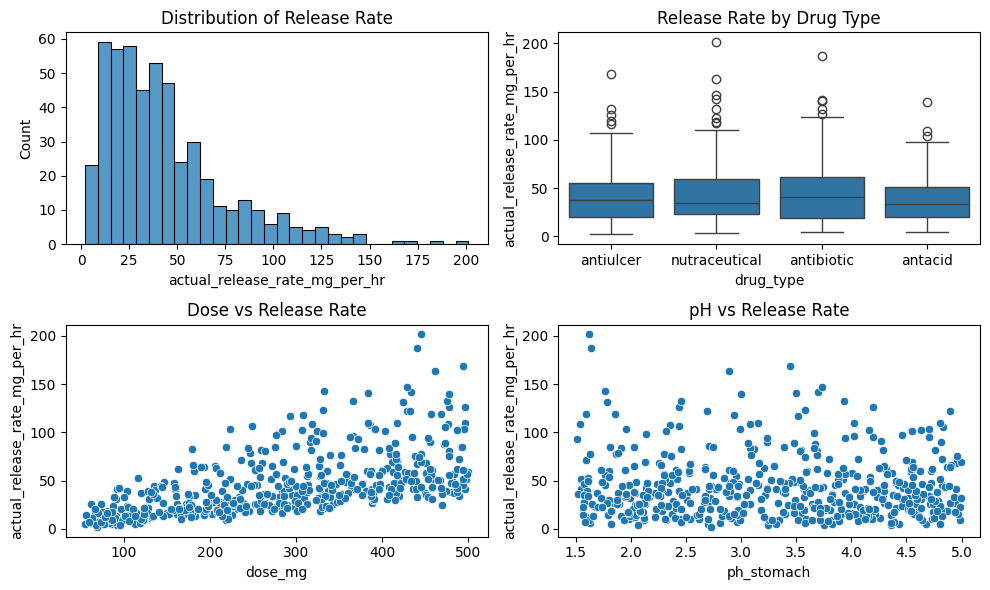

In [15]:
# Plot target distribution
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.histplot(df['actual_release_rate_mg_per_hr'], bins=30)
plt.title('Distribution of Release Rate')

plt.subplot(2,2,2)
sns.boxplot(x='drug_type', y='actual_release_rate_mg_per_hr', data=df)
plt.title('Release Rate by Drug Type')

plt.subplot(2,2,3)
sns.scatterplot(x='dose_mg', y='actual_release_rate_mg_per_hr', data=df)
plt.title('Dose vs Release Rate')

plt.subplot(2,2,4)
sns.scatterplot(x='ph_stomach', y='actual_release_rate_mg_per_hr', data=df)
plt.title('pH vs Release Rate')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

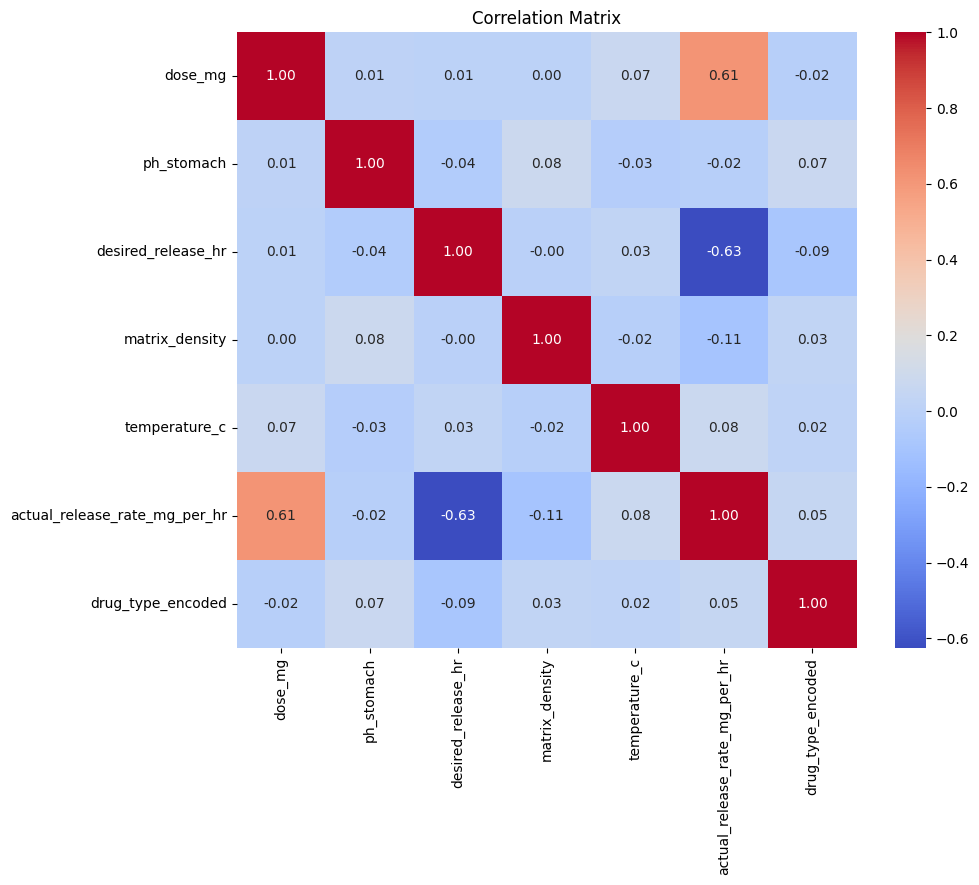

In [16]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

In [17]:
# =====================================
# 5. Prepare Data for Modeling
# =====================================
features = ['dose_mg', 'ph_stomach', 'desired_release_hr', 'matrix_density', 'temperature_c', 'drug_type_encoded']
X = df[features]
y = df['actual_release_rate_mg_per_hr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 400, Test size: 100


In [18]:
# =====================================
# 6. Train Multiple Models with MLflow Tracking
# =====================================

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}


In [19]:
# Store results
results = {}
trained_models = {}

for model_name, model in models.items():
    print(f"\n=== Training {model_name} ===")

    with mlflow.start_run(run_name=model_name):
        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        train_r2 = r2_score(y_train, y_pred_train)

        test_mae = mean_absolute_error(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_r2 = r2_score(y_test, y_pred_test)

        # Cross-validation
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

        # Store results
        results[model_name] = {
            'train_mae': train_mae,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std()
        }

        # Log metrics to MLflow
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("cv_r2_mean", cv_scores.mean())
        mlflow.log_metric("cv_r2_std", cv_scores.std())

        # Log parameters
        mlflow.log_params(model.get_params())

        # Save model to MLflow
        mlflow.sklearn.log_model(model, model_name.replace(" ", "_"))

        # Also save locally in joblib format
        joblib.dump(model, f'{model_name.replace(" ", "_")}.pkl')
        trained_models[model_name] = model

        print(f"Test MAE: {test_mae:.2f}, Test R2: {test_r2:.2f}")
        print(f"CV R2 mean: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")


=== Training Linear Regression ===


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/12 07:39:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 07:39:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/12 07:39:37 WARNING mlflow.models.

Test MAE: 10.99, Test R2: 0.79
CV R2 mean: 0.78 (+/- 0.02)

=== Training Decision Tree ===
Test MAE: 7.01, Test R2: 0.91
CV R2 mean: 0.88 (+/- 0.03)

=== Training Random Forest ===


2026/05/12 07:39:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 07:39:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Test MAE: 4.89, Test R2: 0.96
CV R2 mean: 0.96 (+/- 0.01)

=== Training XGBoost ===


2026/05/12 07:39:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 07:39:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Test MAE: 4.43, Test R2: 0.97
CV R2 mean: 0.96 (+/- 0.01)


In [20]:
# =====================================
# 7. Compare All Models
# =====================================
print("\n=== Model Comparison ===")
comparison_df = pd.DataFrame(results).T
print(comparison_df.sort_values('test_r2', ascending=False))



=== Model Comparison ===
                   train_mae  train_rmse  train_r2   test_mae  test_rmse  \
XGBoost             0.021263    0.031533  0.999999   4.428318   5.879839   
Random Forest       1.822074    2.593027  0.993413   4.889873   6.674468   
Decision Tree       0.000000    0.000000  1.000000   7.008963   9.485998   
Linear Regression  10.785356   14.608401  0.790925  10.988892  14.691135   

                    test_r2  cv_r2_mean  cv_r2_std  
XGBoost            0.966948    0.958365   0.011116  
Random Forest      0.957411    0.956402   0.006398  
Decision Tree      0.913974    0.881420   0.026920  
Linear Regression  0.793665    0.778416   0.018212  


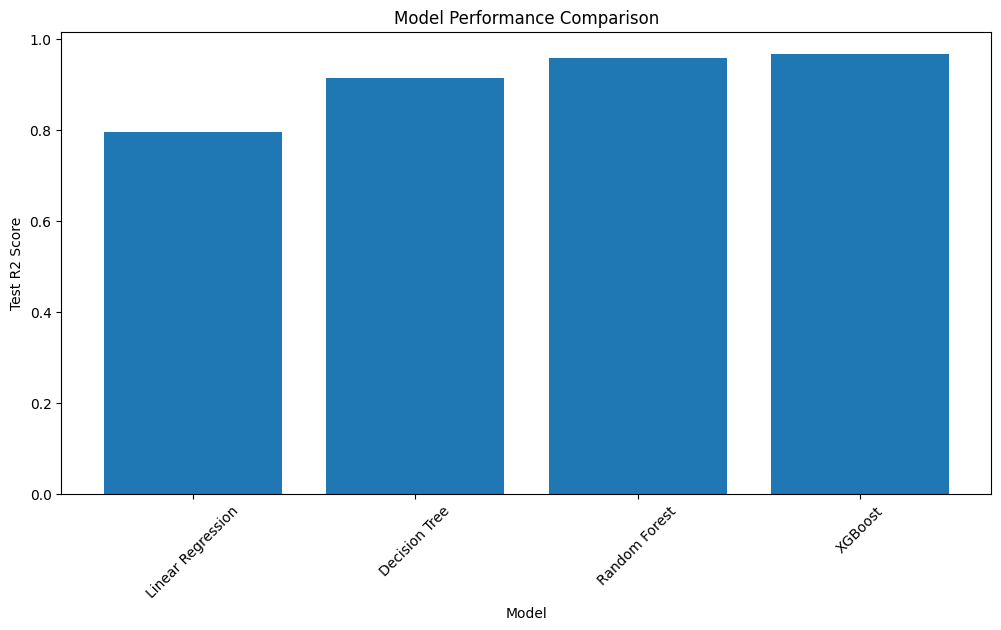

In [21]:
# Plot comparison
plt.figure(figsize=(12,6))
models_names = list(results.keys())
test_r2_scores = [results[m]['test_r2'] for m in models_names]
plt.bar(models_names, test_r2_scores)
plt.xlabel('Model')
plt.ylabel('Test R2 Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.savefig('model_comparison.png')
plt.show()


In [22]:
# =====================================
# 8. Select Best Model
# =====================================
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = trained_models[best_model_name]
print(f"\nBest model: {best_model_name} with R2 score: {results[best_model_name]['test_r2']:.3f}")


Best model: XGBoost with R2 score: 0.967


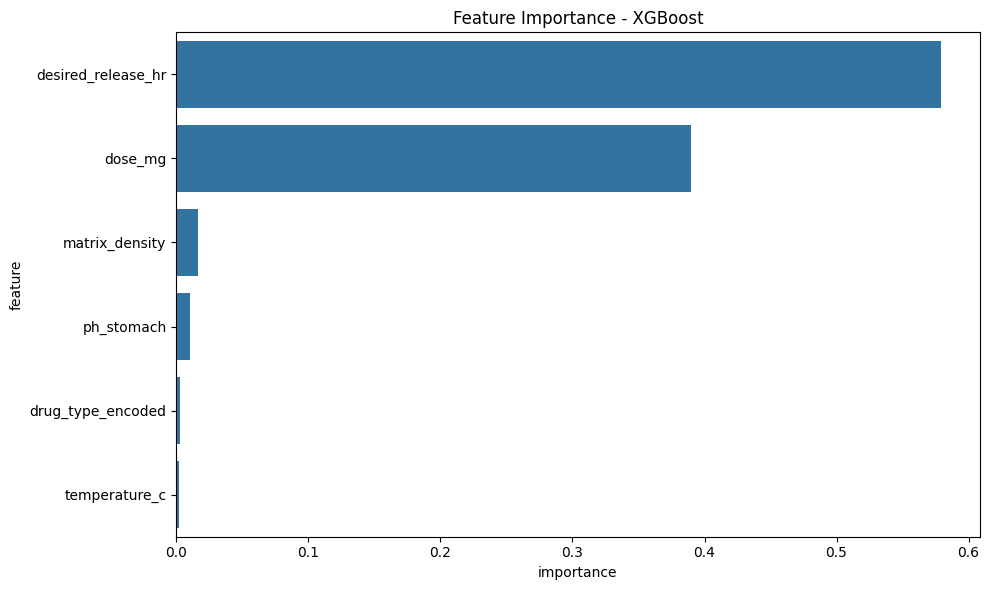


Feature Importance:
              feature  importance
2  desired_release_hr    0.579361
0             dose_mg    0.389906
3      matrix_density    0.016154
1          ph_stomach    0.010121
5   drug_type_encoded    0.002605
4       temperature_c    0.001853


In [23]:
# =====================================
# 9. Feature Importance (for tree-based models)
# =====================================
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=importance_df, x='importance', y='feature')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    print("\nFeature Importance:")
    print(importance_df)

In [24]:
# =====================================
# 10. Save Best Model and Preprocessing Objects
# =====================================
# Save the best model
joblib.dump(best_model, 'gastro_release_best_model.pkl')
print(f"Best model saved as 'gastro_release_best_model.pkl'")

# Save label encoder
joblib.dump(le, 'label_encoder.pkl')
print("Label encoder saved as 'label_encoder.pkl'")

# Save feature columns list
joblib.dump(features, 'feature_columns.pkl')
print("Feature columns saved as 'feature_columns.pkl'")

# Save drug type mapping
joblib.dump(drug_type_mapping, 'drug_type_mapping.pkl')
print("Drug type mapping saved")


Best model saved as 'gastro_release_best_model.pkl'
Label encoder saved as 'label_encoder.pkl'
Feature columns saved as 'feature_columns.pkl'
Drug type mapping saved


In [25]:
# =====================================
# 11. Download all files
# =====================================
from google.colab import files

files.download('gastro_release_best_model.pkl')
files.download('label_encoder.pkl')
files.download('feature_columns.pkl')
files.download('drug_type_mapping.pkl')
files.download('gastroretentive_data.csv')

print("\n=== All files downloaded ===")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== All files downloaded ===


In [26]:
# =====================================
# 12. Test the saved model
# =====================================
print("\n=== Testing saved model ===")
test_input = pd.DataFrame([{
    'dose_mg': 200,
    'ph_stomach': 3.0,
    'desired_release_hr': 6,
    'matrix_density': 0.9,
    'temperature_c': 37,
    'drug_type_encoded': 0  # antibiotic
}])

prediction = best_model.predict(test_input)[0]
print(f"Test prediction: {prediction:.2f} mg/hr")


=== Testing saved model ===
Test prediction: 27.88 mg/hr
